# 02 · Análisis global y rankings

**Pregunta principal del TFM:** ¿qué *sampler* obtiene el mejor rendimiento (hipervolumen) de forma consistente a través de la suite ZCAT?

**Objetivos de este notebook:**

1. Cargar `study_summary.csv` (salida de `01_extraccion_datos.ipynb`).
2. Normalizar el HV de cada problema a la escala [0, 1], para poder comparar problemas de dificultad y escala muy distintas.
3. Calcular el ranking de cada *sampler* dentro de cada problema.
4. Construir una tabla resumen y visualizaciones globales (heatmap, violín, ranking medio).
5. Exportar `study_summary_normalized.csv`, que es el fichero que consumen `03_estadistica.ipynb` y el notebook de hiperparámetros.


## Configuración

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

DATA_DIR = Path("../data/processed")
FIGURES_DIR = Path("../data/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## Carga de datos

In [2]:
study_summary = pd.read_csv(DATA_DIR / "study_summary.csv")
study_summary.head()

,sampler,problem,n_trials,best_value,mean_value,std_value,total_duration,mean_trial_duration
0,cmaes,zcat1,50,0.254027,0.153123,0.089824,4518.993983,90.379879
1,cmaes,zcat10,50,0.112726,0.068460,0.040746,5614.772873,112.295457
2,cmaes,zcat11,50,0.210841,0.117430,0.077371,4183.296339,83.665926
3,cmaes,zcat12,50,0.195056,0.127362,0.072957,3571.041948,71.420838
4,cmaes,zcat13,50,0.249413,0.154064,0.093711,5403.319708,108.066394


In [3]:
print(f"Filas: {study_summary.shape[0]}  |  Columnas: {study_summary.shape[1]}")
print(f"Samplers: {sorted(study_summary['sampler'].unique())}")
print(f"Problemas: {study_summary['problem'].nunique()}")

Filas: 140  |  Columnas: 8
Samplers: ['cmaes', 'gp', 'nsgaii', 'nsgaiii', 'qmc', 'random', 'tpe']
Problemas: 20


## Normalización de hipervolumen

El HV bruto no es comparable entre problemas: cada instancia ZCAT tiene una escala y dificultad distintas. Se normaliza min-max **dentro de cada problema**, de forma que 1.0 siempre corresponde al mejor *sampler* de ese problema y 0.0 al peor.


In [4]:
def normalize_problem_scores(df):
    df = df.copy()
    df["hv_norm"] = (
        df.groupby("problem")["best_value"]
        .transform(lambda x: (x - x.min()) / (x.max() - x.min()))
    )
    return df


study_summary = normalize_problem_scores(study_summary)
study_summary[["sampler", "problem", "best_value", "hv_norm"]].head()

,sampler,problem,best_value,hv_norm
0,cmaes,zcat1,0.254027,0.505914
1,cmaes,zcat10,0.112726,0.870393
2,cmaes,zcat11,0.210841,0.000000
3,cmaes,zcat12,0.195056,0.439294
4,cmaes,zcat13,0.249413,0.830539


## Ranking por problema

Para cada problema, se asigna un rango de 1 (mejor) a 7 (peor) a cada *sampler* según su `best_value`. `method="average"` reparte el rango entre empates.


In [5]:
def compute_rank(df):
    df = df.copy()
    df["rank"] = (
        df.groupby("problem")["best_value"]
        .rank(ascending=False, method="average")
    )
    return df


study_summary = compute_rank(study_summary)

In [6]:
mean_rank = (
    study_summary
    .groupby("sampler")["rank"]
    .mean()
    .sort_values()
)

print("Ranking medio por sampler (menor es mejor):")
mean_rank

Ranking medio por sampler (menor es mejor):


sampler
tpe        2.40
gp         3.95
cmaes      4.05
nsgaii     4.25
random     4.35
qmc        4.40
nsgaiii    4.60
Name: rank, dtype: float64

## Tabla resumen

In [7]:
summary = (
    study_summary
    .groupby("sampler")
    .agg(
        mean_rank=("rank", "mean"),
        median_rank=("rank", "median"),
        mean_hv=("best_value", "mean"),
        median_hv=("best_value", "median"),
        std_hv=("best_value", "std"),
        mean_norm=("hv_norm", "mean"),
        std_norm=("hv_norm", "std"),
        best_problem=("hv_norm", "max"),
        worst_problem=("hv_norm", "min"),
        mean_total_duration=("total_duration", "mean"),
    )
    .sort_values("mean_rank")
)

summary

,mean_rank,median_rank,mean_hv,median_hv,std_hv,mean_norm,std_norm,best_problem,worst_problem,mean_total_duration
sampler,,,,,,,,,,
tpe,2.40,2.0,0.298424,0.208194,0.247446,0.801425,0.225655,1.0,0.208151,5120.766135
gp,3.95,4.0,0.294712,0.208154,0.246478,0.541679,0.365896,1.0,0.000000,11300.209126
cmaes,4.05,4.0,0.296530,0.203634,0.246902,0.574209,0.355779,1.0,0.000000,4835.557969
nsgaii,4.25,4.5,0.296515,0.205967,0.247738,0.512455,0.354414,1.0,0.000000,5353.103803
random,4.35,4.0,0.296337,0.204608,0.247643,0.454779,0.359745,1.0,0.000000,5300.492892
qmc,4.40,4.5,0.295987,0.208090,0.245801,0.465911,0.329680,1.0,0.000000,5465.212288
nsgaiii,4.60,5.0,0.296388,0.204769,0.247522,0.439524,0.398803,1.0,0.000000,4863.118053


## Heatmap: hipervolumen normalizado por problema y sampler

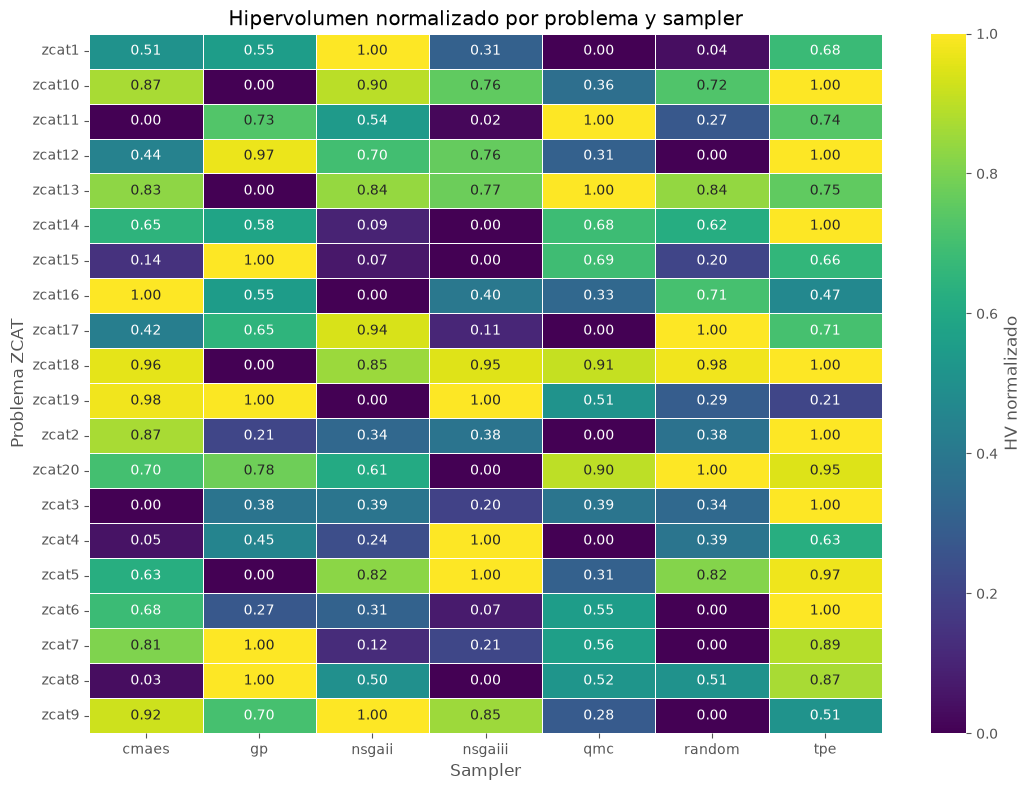

In [8]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    study_summary.pivot(index="problem", columns="sampler", values="hv_norm"),
    cmap="viridis",
    linewidths=.5,
    cbar_kws={"label": "HV normalizado"},
    annot=True,
    fmt=".2f",
)

plt.title("Hipervolumen normalizado por problema y sampler")
plt.xlabel("Sampler")
plt.ylabel("Problema ZCAT")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_hv.png", dpi=300)
plt.show()

## Distribución del HV normalizado por sampler

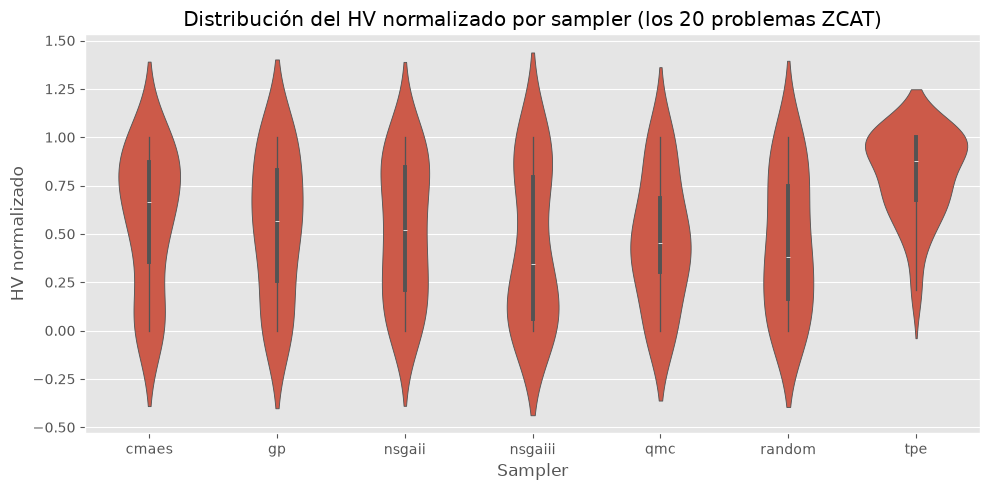

In [9]:
plt.figure(figsize=(10, 5))

sns.violinplot(
    data=study_summary,
    x="sampler",
    y="hv_norm",
)

plt.title("Distribución del HV normalizado por sampler (los 20 problemas ZCAT)")
plt.xlabel("Sampler")
plt.ylabel("HV normalizado")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rank_boxplot.png", dpi=300)
plt.show()

## Ranking medio por sampler

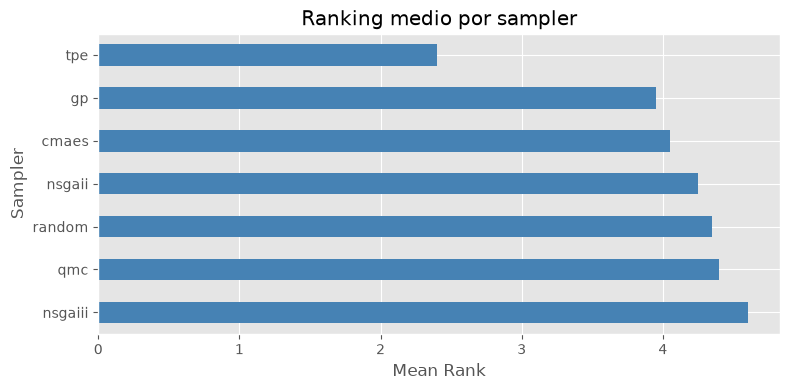

In [13]:
plt.figure(figsize=(8, 4))

mean_rank.plot.barh(color="steelblue")

plt.title("Ranking medio por sampler")
plt.xlabel("Mean Rank")
plt.ylabel("Sampler")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mean_rank.png", dpi=300)
plt.show()

## Matriz de ranking por problema

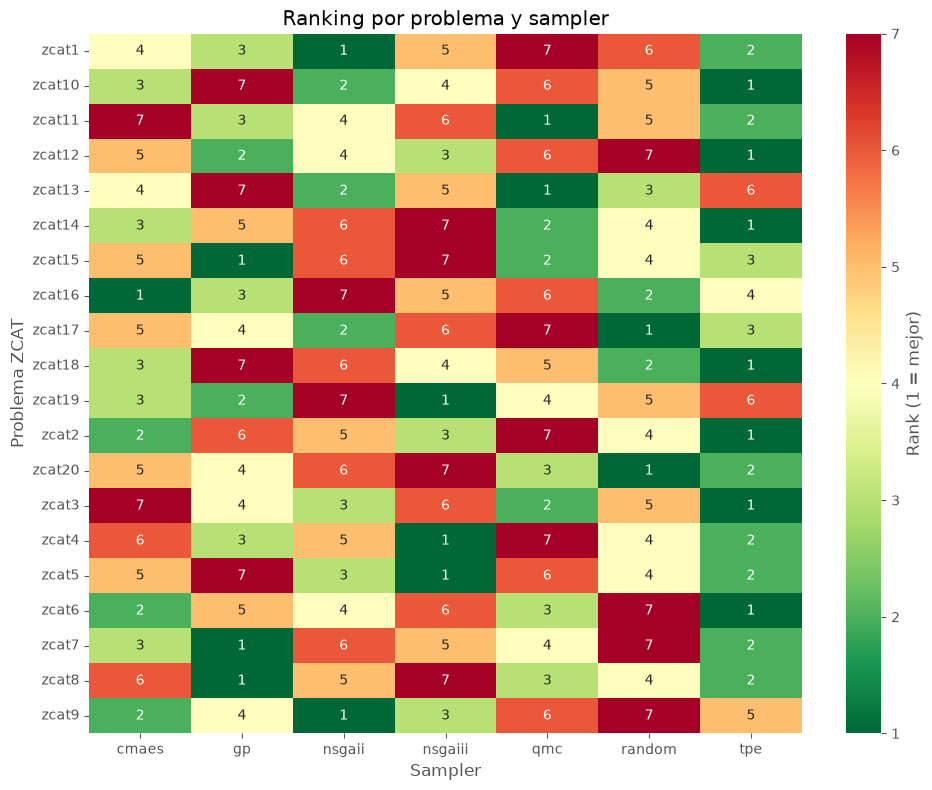

sampler,cmaes,gp,nsgaii,nsgaiii,qmc,random,tpe
problem,,,,,,,
zcat1,4.0,3.0,1.0,5.0,7.0,6.0,2.0
zcat10,3.0,7.0,2.0,4.0,6.0,5.0,1.0
zcat11,7.0,3.0,4.0,6.0,1.0,5.0,2.0
zcat12,5.0,2.0,4.0,3.0,6.0,7.0,1.0
zcat13,4.0,7.0,2.0,5.0,1.0,3.0,6.0
zcat14,3.0,5.0,6.0,7.0,2.0,4.0,1.0
zcat15,5.0,1.0,6.0,7.0,2.0,4.0,3.0
zcat16,1.0,3.0,7.0,5.0,6.0,2.0,4.0
zcat17,5.0,4.0,2.0,6.0,7.0,1.0,3.0


In [11]:
rank_matrix = study_summary.pivot(index="problem", columns="sampler", values="rank")

plt.figure(figsize=(10, 8))

sns.heatmap(
    rank_matrix,
    annot=True,
    cmap="RdYlGn_r",
    cbar_kws={"label": "Rank (1 = mejor)"},
)

plt.title("Ranking por problema y sampler")
plt.xlabel("Sampler")
plt.ylabel("Problema ZCAT")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "heatmap_rank.png", dpi=300)
plt.show()

rank_matrix

## Exportar resultados

In [12]:
summary.to_csv(DATA_DIR / "ranking_summary.csv")

study_summary_export = study_summary.rename(columns={"best_value": "hv"})
study_summary_export.to_csv(DATA_DIR / "study_summary_normalized.csv", index=False)

print(f"Guardado: {(DATA_DIR / 'ranking_summary.csv').resolve()}")
print(f"Guardado: {(DATA_DIR / 'study_summary_normalized.csv').resolve()}")

Guardado: D:\tfm\tfm\data\processed\ranking_summary.csv
Guardado: D:\tfm\tfm\data\processed\study_summary_normalized.csv


## Conclusiones de este notebook

- El **ranking medio** (`mean_rank`) identifica qué *sampler* es sistemáticamente mejor a través de los 20 problemas ZCAT.
- El heatmap de HV normalizado permite detectar si algún *sampler* domina en subconjuntos concretos de problemas.
- `study_summary_normalized.csv` es ya el fichero definitivo de referencia (`hv`, `hv_norm`, `rank`) para los siguientes notebooks: la significancia estadística de estas diferencias se contrasta formalmente en `03_estadistica.ipynb`.
